In [1]:
pip install jax equinox diffrax optax matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 15.4 MB/s eta 0:00:00


In [2]:
import os
import glob

# Path to the dataset directory
dataset_path = '/content/drive/MyDrive/ap_dataset/'

# List all .mat files in the directory
mat_files = glob.glob(os.path.join(dataset_path, '*.mat'))

print(f"Found {len(mat_files)} .mat files:")
for f in mat_files[:5]: # Print first 5 files as an example
    print(os.path.basename(f))


Found 100 .mat files:
spiral_data_001.mat
spiral_data_002.mat
spiral_data_003.mat
spiral_data_004.mat
spiral_data_005.mat


In [3]:
import scipy.io
import jax.numpy as jnp

first_mat_file = mat_files[0]
data = scipy.io.loadmat(first_mat_file)
print(f"\nContent of {os.path.basename(first_mat_file)}:")
for key, value in data.items():
    if not key.startswith('__'):
        print(f"  Key: {key}, Type: {type(value)}, Shape: {getattr(value, 'shape', 'N/A')}, Dtype: {getattr(value, 'dtype', 'N/A')}")

key_to_convert = None
for k in data.keys():
    if not k.startswith('__') and isinstance(data[k], (list, tuple, dict, object)) and 'spiral_data' in k.lower():
        key_to_convert = k
        break
    elif not k.startswith('__') and isinstance(data[k], (list, tuple, dict, object)) and 'data' in k.lower():
        key_to_convert = k
        break
    elif not k.startswith('__') and isinstance(data[k], (list, tuple, dict, object)) and 'X' in k:
        key_to_convert = k
        break

if key_to_convert:
    numpy_array = data[key_to_convert]
    print(f"\nAttempting to convert key '{key_to_convert}' to JAX array...")
    try:
        jax_array = jnp.asarray(numpy_array)
        print(f"Successfully converted '{key_to_convert}' to JAX array. Shape: {jax_array.shape}, Dtype: {jax_array.dtype}")
        print("First 5 elements (or full array if small):")
        print(jax_array[:5] if jax_array.ndim > 0 and jax_array.shape[0] > 5 else jax_array)
    except Exception as e:
        print(f"Failed to convert '{key_to_convert}' to JAX array: {e}")




Content of spiral_data_001.mat:
  Key: D, Type: <class 'numpy.ndarray'>, Shape: (102, 102), Dtype: float64
  Key: Dfac, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: Vsav, Type: <class 'numpy.ndarray'>, Shape: (100, 100, 1496), Dtype: float64
  Key: Wsav, Type: <class 'numpy.ndarray'>, Shape: (100, 100, 1496), Dtype: float64
  Key: a, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: b, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: dt, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: epsi, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: h, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: k, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: uint8
  Key: mu1, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: mu2, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: float64
  Key: tCF, Type: <class 'numpy.ndarray'>, Shape: (1, 1), Dtype: uint8
  Key

In [4]:
for k in data.keys():
  if k.startswith('__'):
    continue
  arr = data[k]
  jaxarr= jnp.asarray(arr)
  if jaxarr.shape[0]>5:
    print(f"Key: {k}, Shape: {jaxarr.shape}, Dtype: {jaxarr.dtype}")
    print(jaxarr[:5])
  else:
    print(f"Key: {k}, Shape: {jaxarr.shape}, Dtype: {jaxarr.dtype}")
    print(jaxarr)


Key: D, Shape: (102, 102), Dtype: float32
[[0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15]
 [0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
  0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15

In [5]:
import numpy as np

train_data = []
valid_data = []
test_data = []
for i in range(0, 80):
  data = scipy.io.loadmat(mat_files[i])
  Vsav_temp = data['Vsav']
  Wsav_temp = data['Wsav']
  Vsav_temp = np.transpose(Vsav_temp, (2, 0, 1))
  Wsav_temp = np.transpose(Wsav_temp, (2, 0, 1))
  train_data.append((Vsav_temp, Wsav_temp))
for j in range(80, 90):
  data = scipy.io.loadmat(mat_files[j])
  Vsav_temp = data['Vsav']
  Wsav_temp = data['Wsav']
  Vsav_temp = np.transpose(Vsav_temp, (2, 0, 1))
  Wsav_temp = np.transpose(Wsav_temp, (2, 0, 1))
  valid_data.append((Vsav_temp, Wsav_temp))
for k in range(90, 100):
  data = scipy.io.loadmat(mat_files[k])
  Vsav_temp = data['Vsav']
  Wsav_temp = data['Wsav']
  Vsav_temp = np.transpose(Vsav_temp, (2, 0, 1))
  Wsav_temp = np.transpose(Wsav_temp, (2, 0, 1))
  test_data.append((Vsav_temp, Wsav_temp))
train_data = np.array(train_data)
valid_data = np.array(valid_data)
test_data = np.array(test_data)
print("Train shape: ", train_data.shape)
print("Valid shape: ", valid_data.shape)
print("Test shape: ", test_data.shape)




Train shape:  (80, 2, 1496, 100, 100)
Valid shape:  (10, 2, 1496, 100, 100)
Test shape:  (10, 2, 1496, 100, 100)


In [6]:
#We use CPU so far.
def flatten4d(tensor):
  tensor = np.transpose(tensor, (0, 2, 1, 3, 4))
  tensor = tensor.reshape(-1, 2, 100, 100)
  return tensor
test_data = flatten4d(test_data)
train_data = flatten4d(train_data)
valid_data = flatten4d(valid_data)
print("Train shape: ", train_data.shape)
print("Valid shape: ", valid_data.shape)
print("Test shape: ", test_data.shape)

Train shape:  (119680, 2, 100, 100)
Valid shape:  (14960, 2, 100, 100)
Test shape:  (14960, 2, 100, 100)


In [7]:
#Don't need this - slows down JAX.
from torch.utils.data import DataLoader, TensorDataset
import torch

train_dataset = TensorDataset(torch.tensor(train_data))
valid_dataset = TensorDataset(torch.tensor(valid_data))
test_dataset = TensorDataset(torch.tensor(test_data))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [8]:
pip install equinox

In [15]:
import equinox as eqx
import jax

class Encoder(eqx.Module):
  layers:list
  def __init__(self, key):
    keys = jax.random.split(key, 3)
    self.layers = [
        eqx.nn.Conv2d(2, 16, kernel_size=3, stride=2,padding =1, key=keys[0]),
        jax.nn.silu,
        eqx.nn.Conv2d(16, 32, kernel_size=3, stride=2,padding =1, key=keys[1]),
        jax.nn.silu,
        eqx.nn.Conv2d(32, 64, kernel_size=3, stride=2,padding =1, key=keys[2])
    ]
  def __call__(self, x):
    for layer in self.layers:
      x=layer(x)
    return x

class Decoder(eqx.Module):
  layers:list
  def __init__(self, key):
    keys = jax.random.split(key, 3)
    self.layers = [
        eqx.nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1,key=keys[0]),
        jax.nn.silu,
        eqx.nn.ConvTranspose2d(32, 16, kernel_size= 3, stride=2, padding=1, output_padding=1, key=keys[1]),
        jax.nn.silu,
        eqx.nn.ConvTranspose2d(16, 2, kernel_size= 3, stride=2, padding=1, output_padding=1, key=keys[2])
    ]
  def __call__(self, x):
    for layer in self.layers:
      x=layer(x)
    return x



In [10]:
pip install optax

Epoch 0, Step 100, Training Loss: 0.007928239181637764, Validation Loss: 0.005192513203068161
Epoch 0, Step 200, Training Loss: 0.0012933524558320642, Validation Loss: 0.0020297268001818764
Epoch 0, Step 300, Training Loss: 0.0010988782159984112, Validation Loss: 0.001073782250157695
Epoch 0, Step 400, Training Loss: 0.000904429005458951, Validation Loss: 0.0007819167360730328
Epoch 0, Step 500, Training Loss: 0.0004425729566719383, Validation Loss: 0.0005557277871798566
Epoch 0, Step 600, Training Loss: 0.0005814102478325367, Validation Loss: 0.00046602181485538423
Epoch 0, Step 700, Training Loss: 0.0003403175505809486, Validation Loss: 0.0003931126438550968
Epoch 0, Step 800, Training Loss: 0.00021696848853025585, Validation Loss: 0.0003392767818479861
Epoch 0, Step 900, Training Loss: 0.00016542663797736168, Validation Loss: 0.00031229654919077136
Epoch 0, Step 1000, Training Loss: 0.0001928126293933019, Validation Loss: 0.0002699334371653903
Epoch 0, Step 1100, Training Loss: 0.00

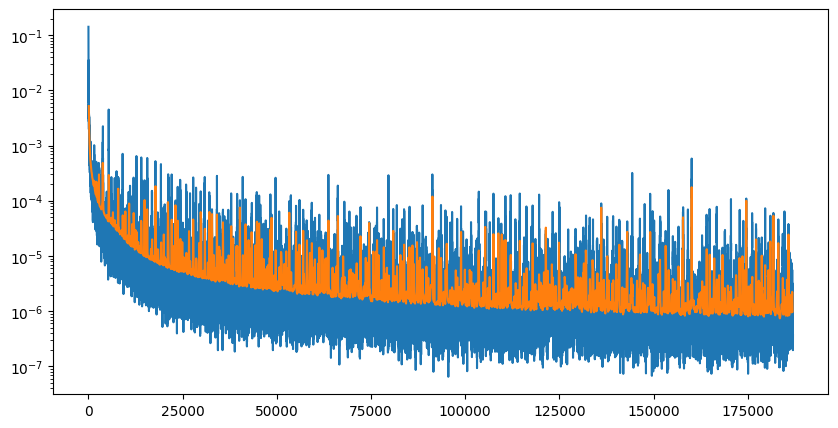

In [20]:
import optax
import equinox as eqx
import jax
import matplotlib.pyplot as plt

encoder_key, decoder_key = jax.random.split(jax.random.PRNGKey(42))
encoder=Encoder(encoder_key)
decoder =Decoder(decoder_key)
start_lr = 1e-3
optimizer = optax.adam(start_lr)
ae_params = (encoder, decoder)
opt_state = optimizer.init(eqx.filter(ae_params, eqx.is_array))
def autoencoder_loss(params, x, y):
  encoder, decoder = params
  z = jax.vmap(encoder)(x)
  y_hat = jax.vmap(decoder)(z)
  loss = jnp.mean(optax.l2_loss(y_hat, y))
  return loss

num_epochs = 50
step = 0
j = 0
loss = 0
train_steps=[]
valid_steps=[]
train_loss = []
valid_loss = []
batch_size=32
train_data_gpu = jax.device_put(train_data)
valid_data_gpu = jax.device_put(valid_data)

@eqx.filter_jit
def trainstep(params, opt_state, batch):
  loss, grads = eqx.filter_value_and_grad(autoencoder_loss)(params, batch, batch)
  updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(params, eqx.is_array))
  params=eqx.apply_updates(params, updates)
  return loss, params, opt_state

@eqx.filter_jit
def valid_update(params, batch):
  loss = autoencoder_loss(params, batch, batch)
  return loss

for epoch in range(num_epochs):
  perm = np.random.permutation(train_data_gpu.shape[0])
  for i in range(0, train_data_gpu.shape[0], batch_size):
    batch = train_data_gpu[perm[i:i+batch_size]]
    loss, ae_params, opt_state = trainstep(ae_params, opt_state, batch)
    train_steps.append(step)
    train_loss.append(loss.item())
    if step%100 == 0 and step != 0:
      val = 0
      num = 0
      for j in range(0, valid_data_gpu.shape[0], batch_size):
        interval = min(batch_size, valid_data_gpu.shape[0] - j)
        batch_valid = valid_data_gpu[j:j+interval]
        val += valid_update(ae_params, batch_valid).item()
        num += 1
      val = val/num
      valid_loss.append(val)
      valid_steps.append(step)
      print(f"Epoch {epoch}, Step {step}, Training Loss: {loss.item()}, Validation Loss: {val}")
    step+=1



t_steps = np.array(train_steps)
t_loss = np.array(train_loss)
v_steps = np.array(valid_steps)
v_loss = np.array(valid_loss)

plt.figure(figsize=(10, 5))
plt.plot(t_steps, t_loss, label='Training Loss')
plt.plot(v_steps, v_loss, label='Validation Loss')
plt.yscale('log')




In [21]:
eqx.tree_serialise_leaves("cardiac_autoencoder.eqx", ae_params)

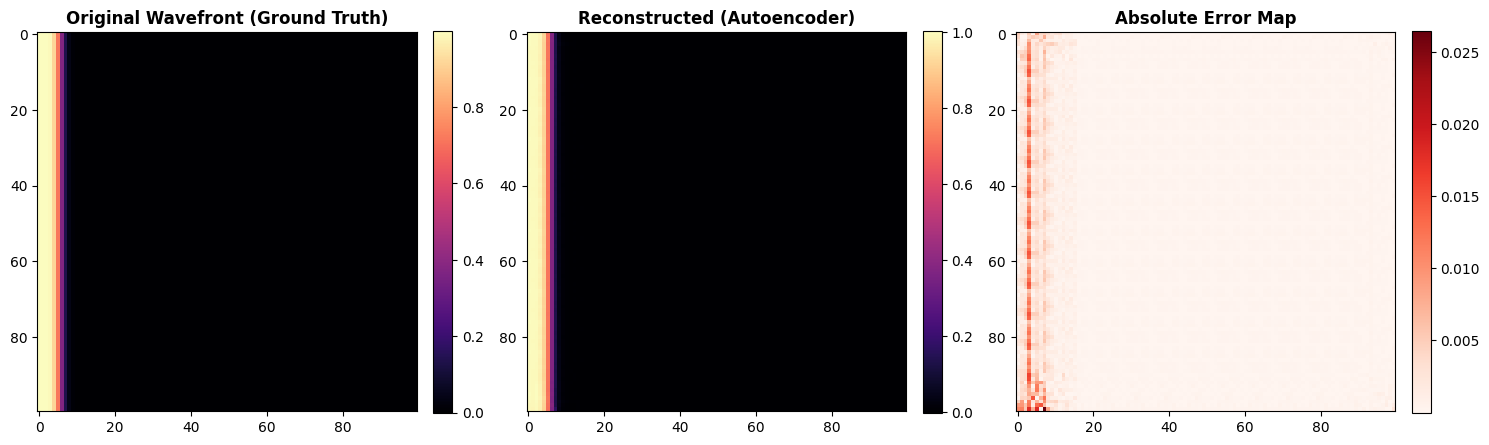

In [25]:
trained_encoder, trained_decoder = ae_params
activity_levels = jnp.max(valid_data_gpu[:, 0, :, :], axis=(1, 2))
best_idx = jnp.argmax(activity_levels).item()
sample_batch = valid_data_gpu[best_idx:best_idx+1]
z = jax.vmap(trained_encoder)(sample_batch)
reconstruction = jax.vmap(trained_decoder)(z)
orig_img = np.array(sample_batch[0, 0])
recon_img = np.array(reconstruction[0, 0])
error_map = np.abs(orig_img - recon_img)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(orig_img, cmap='magma', vmin=orig_img.min(), vmax=orig_img.max())
axes[0].set_title('Original Wavefront (Ground Truth)', fontweight='bold')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(recon_img, cmap='magma', vmin=recon_img.min(), vmax=recon_img.max())
axes[1].set_title('Reconstructed (Autoencoder)', fontweight='bold')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow(error_map, cmap='Reds')
axes[2].set_title('Absolute Error Map', fontweight='bold')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Hunting for spirals...


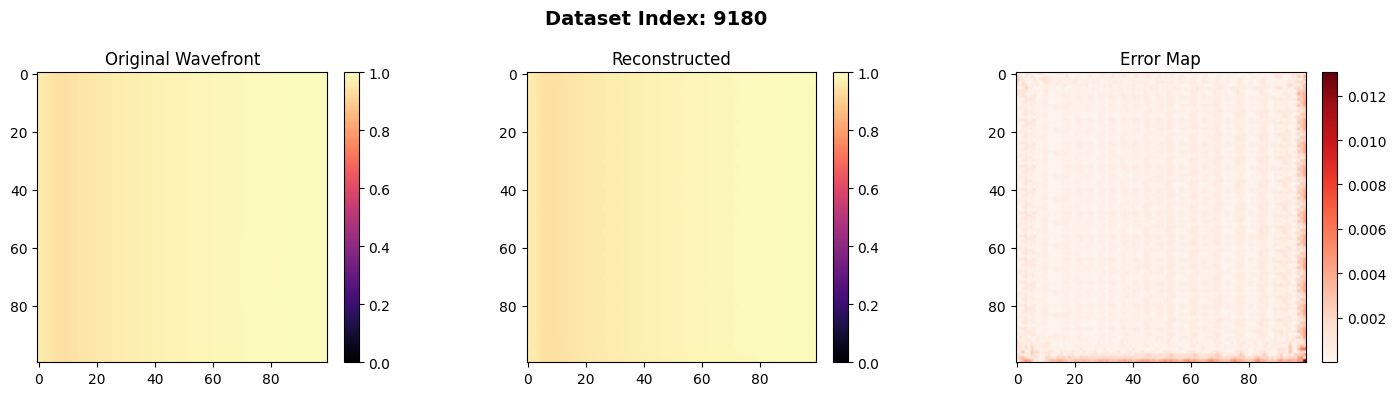

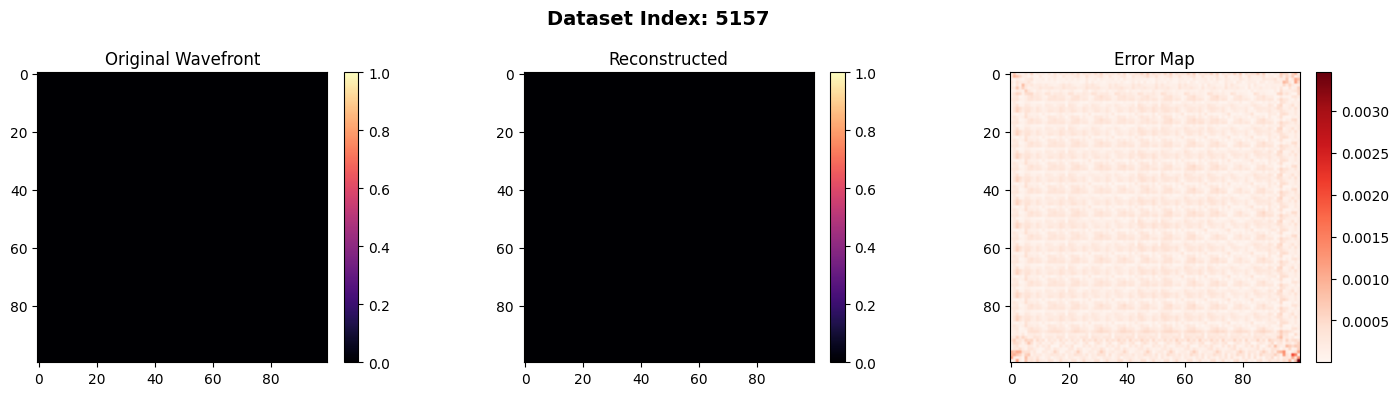

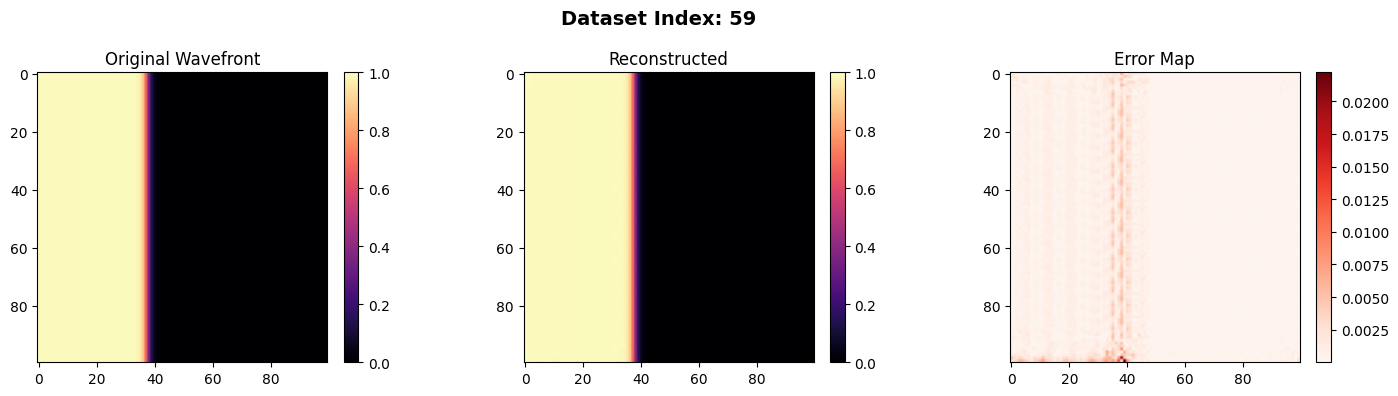

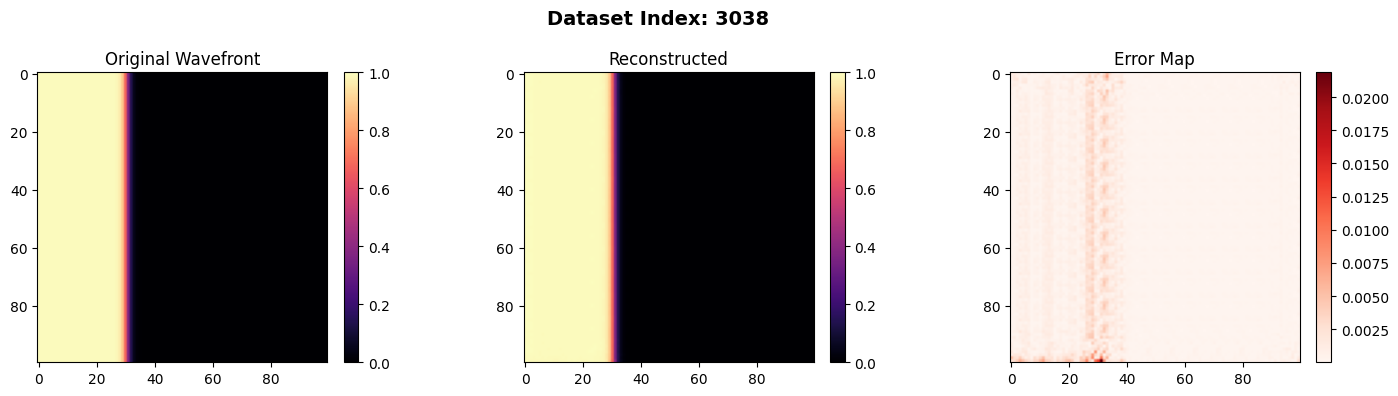

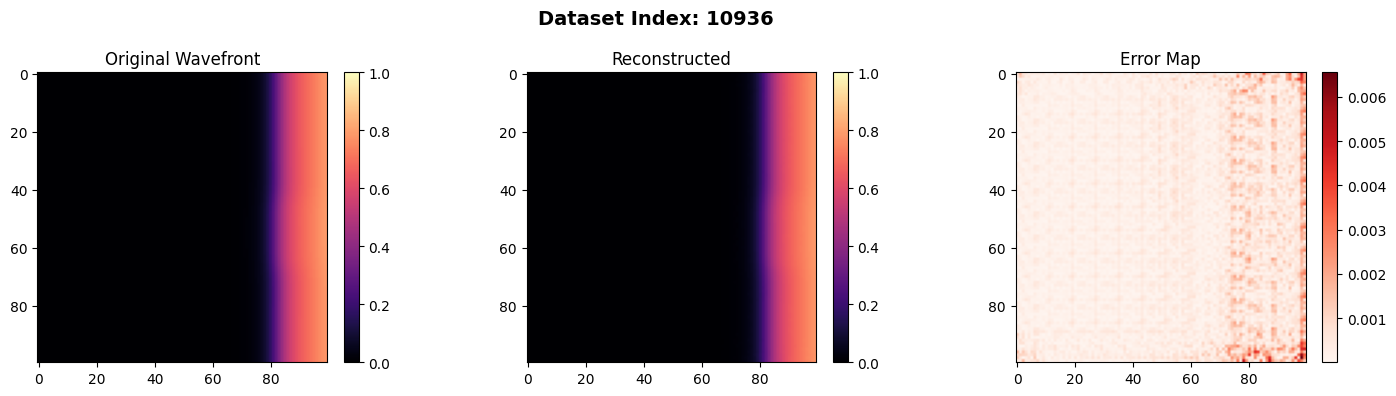

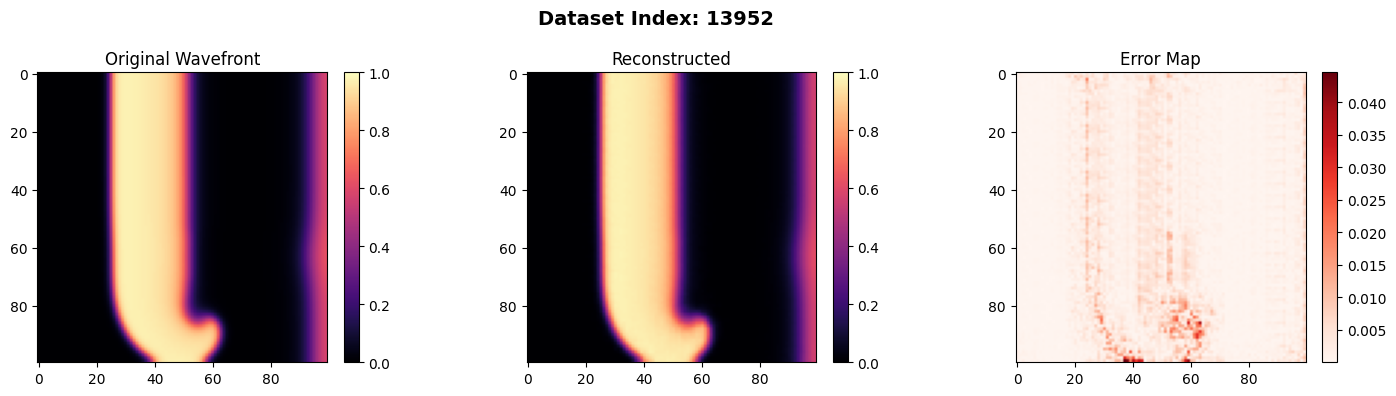

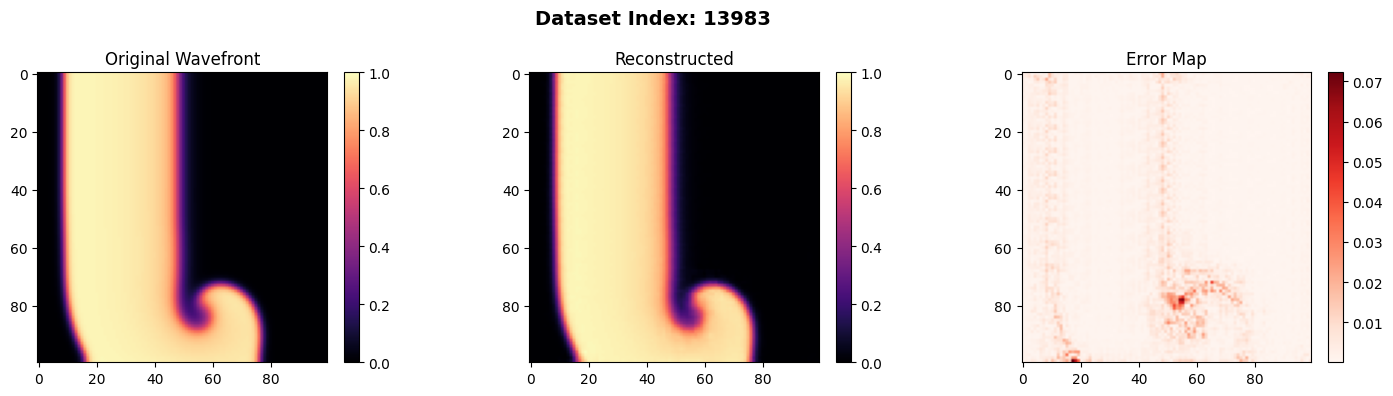

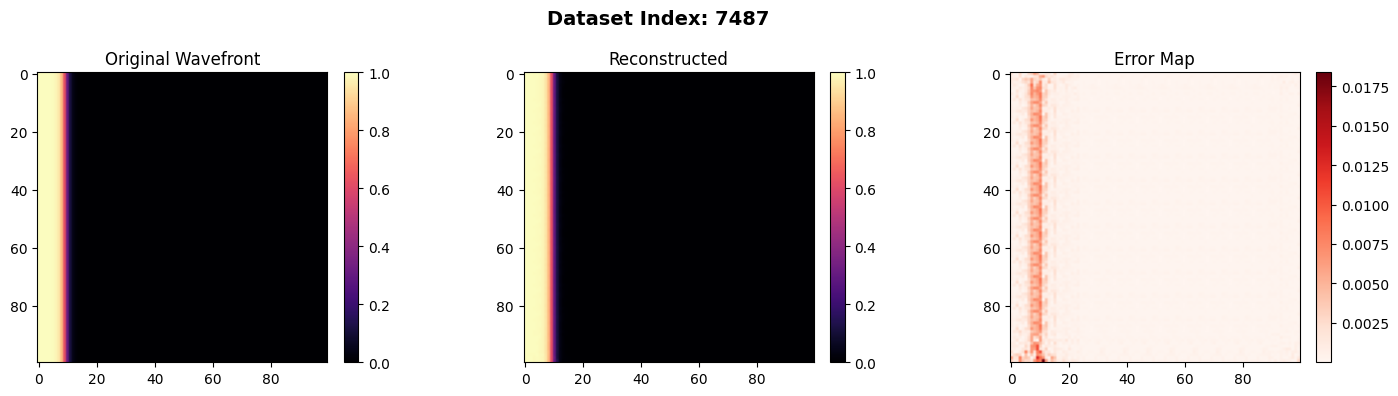

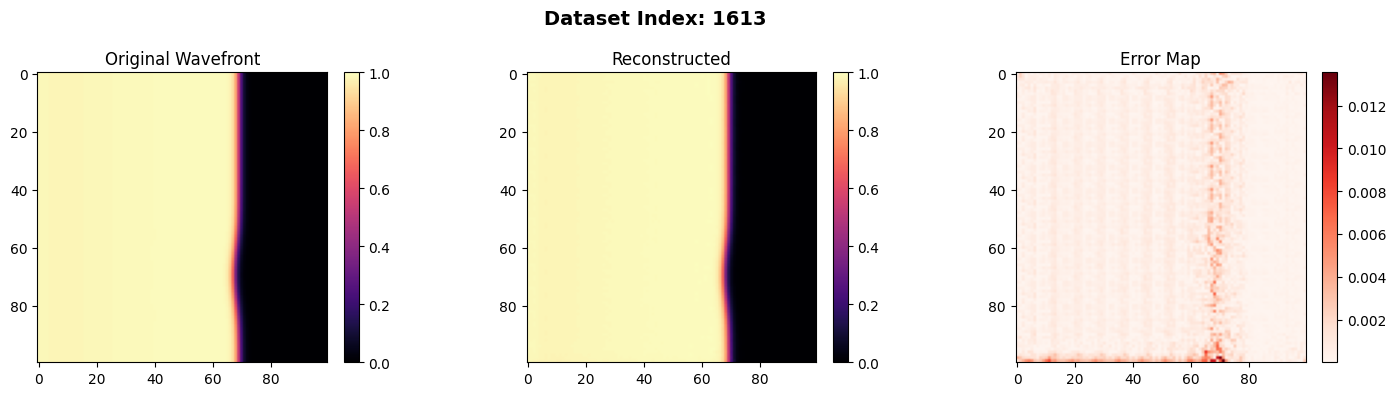

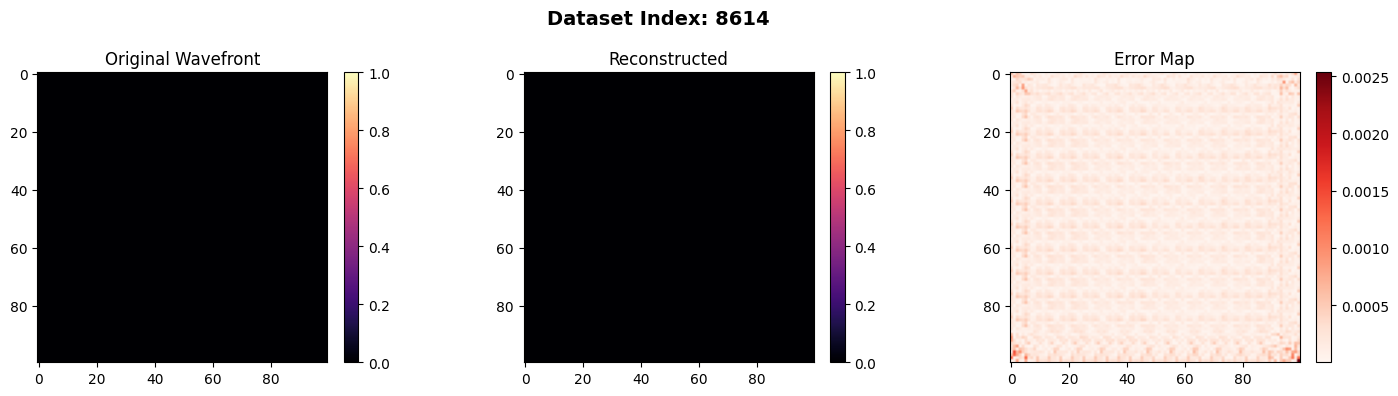

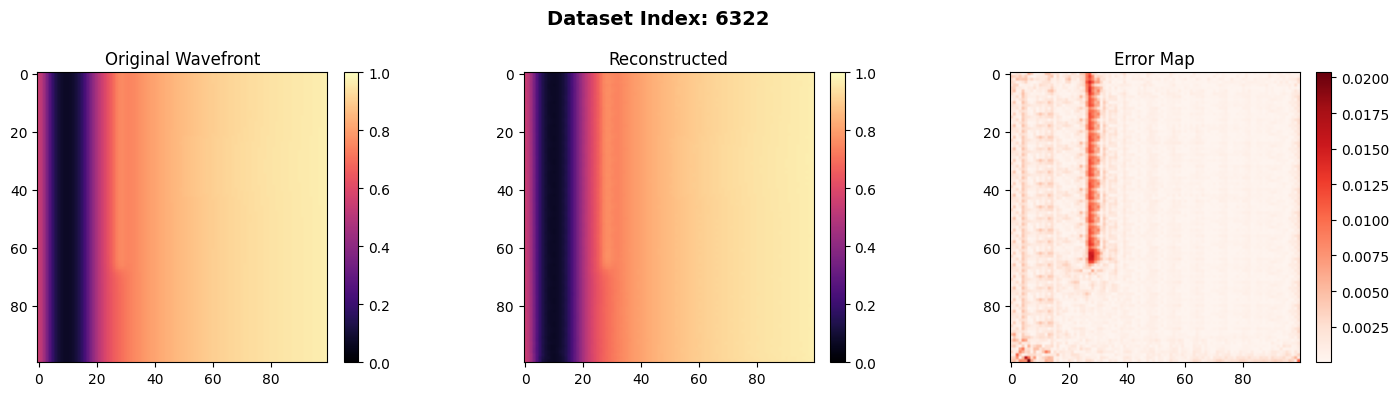

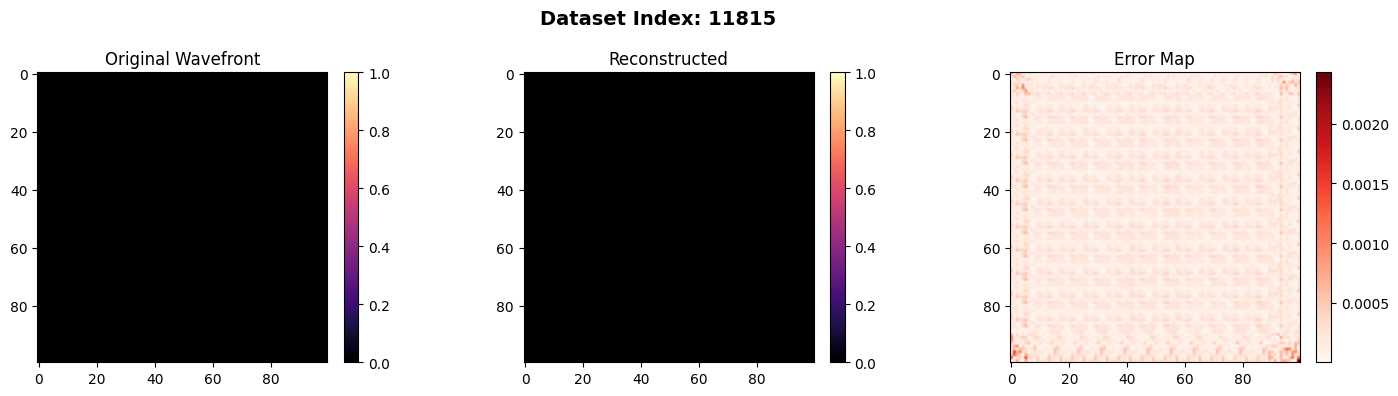

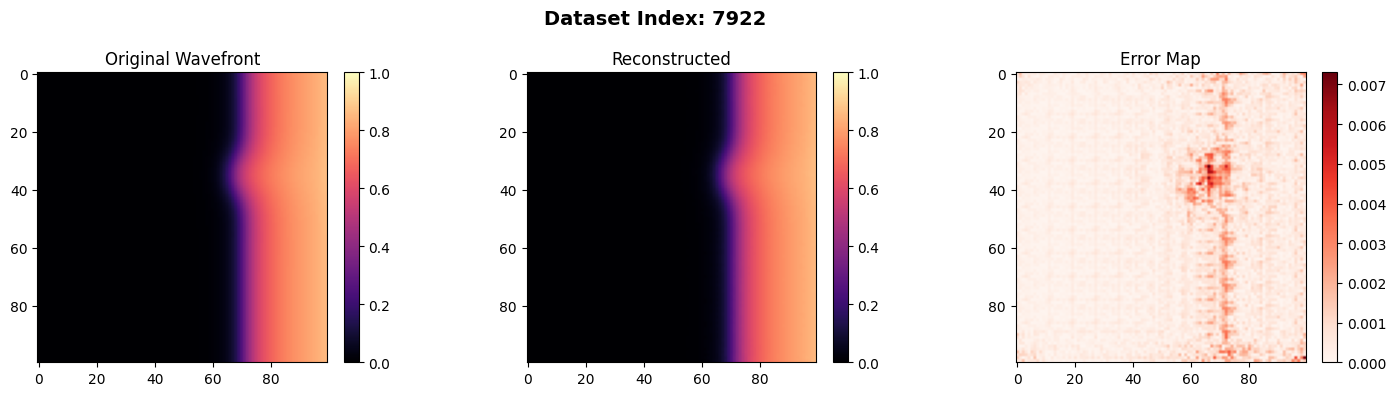

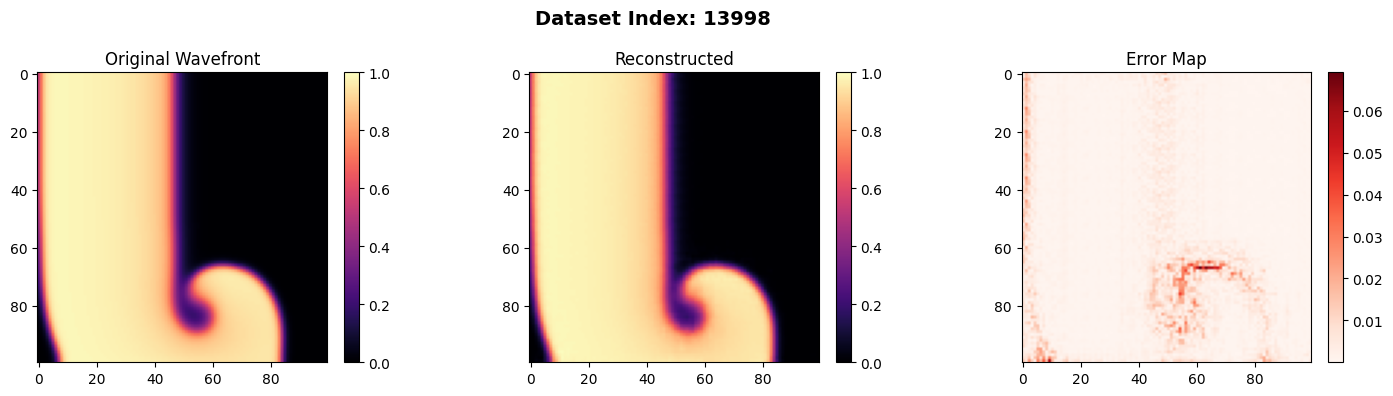

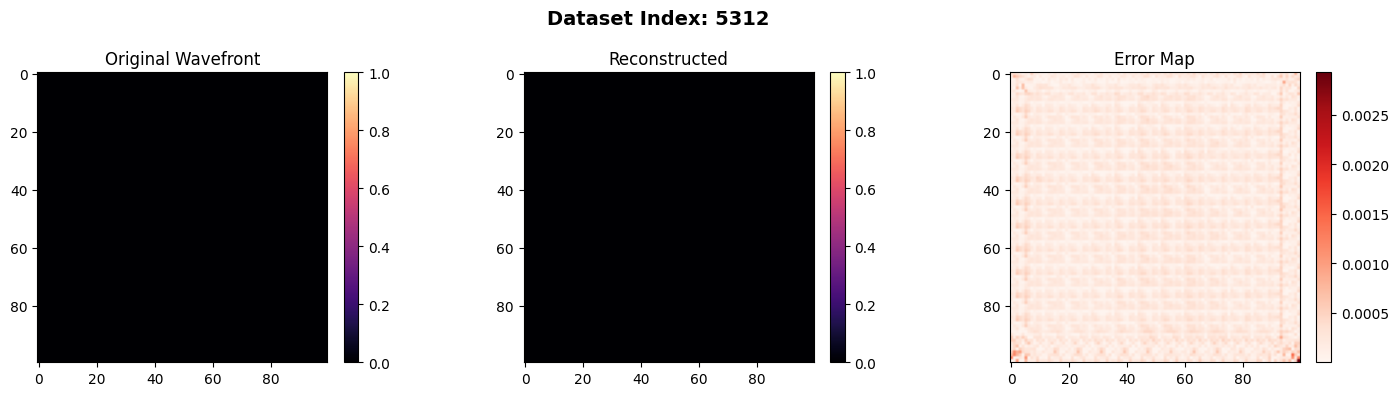

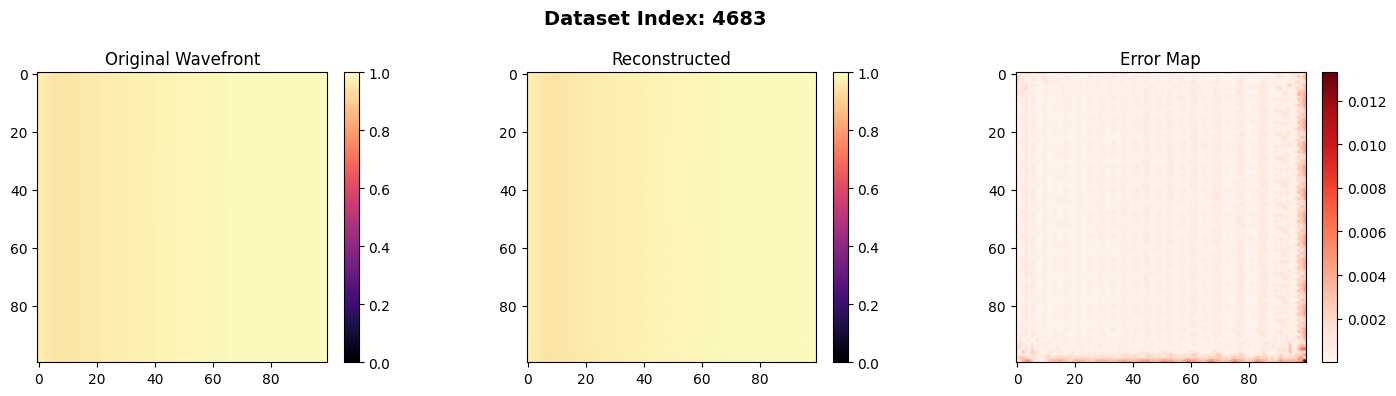

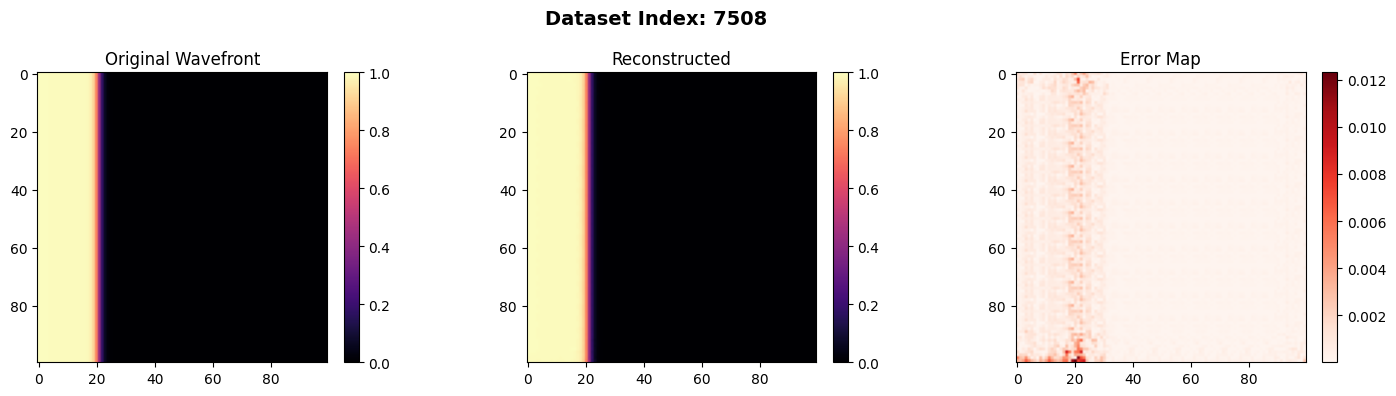

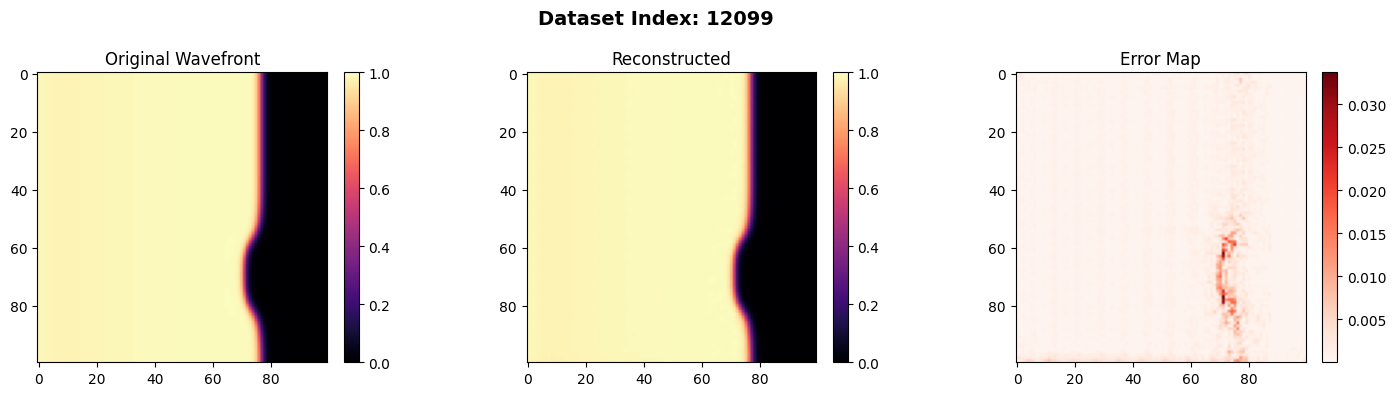

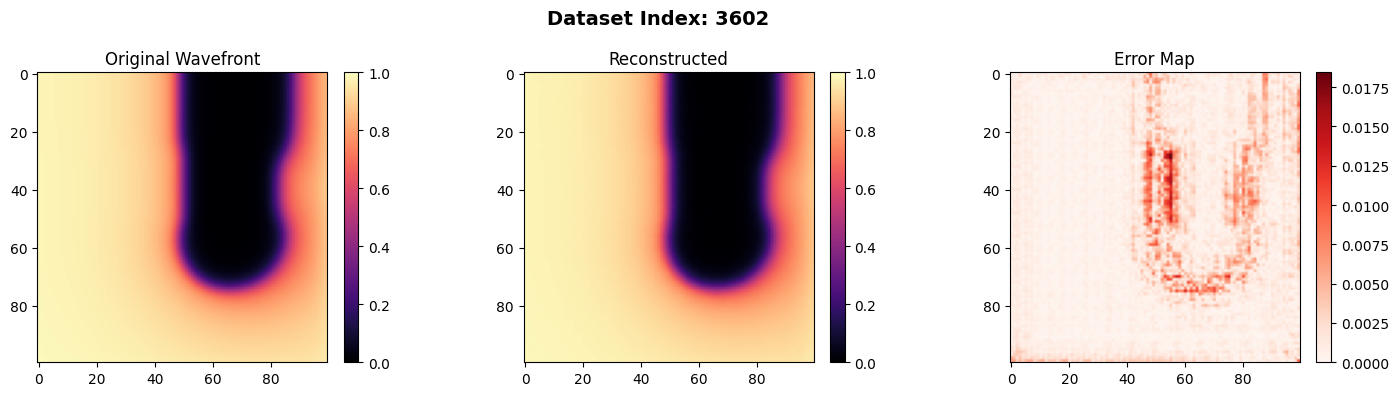

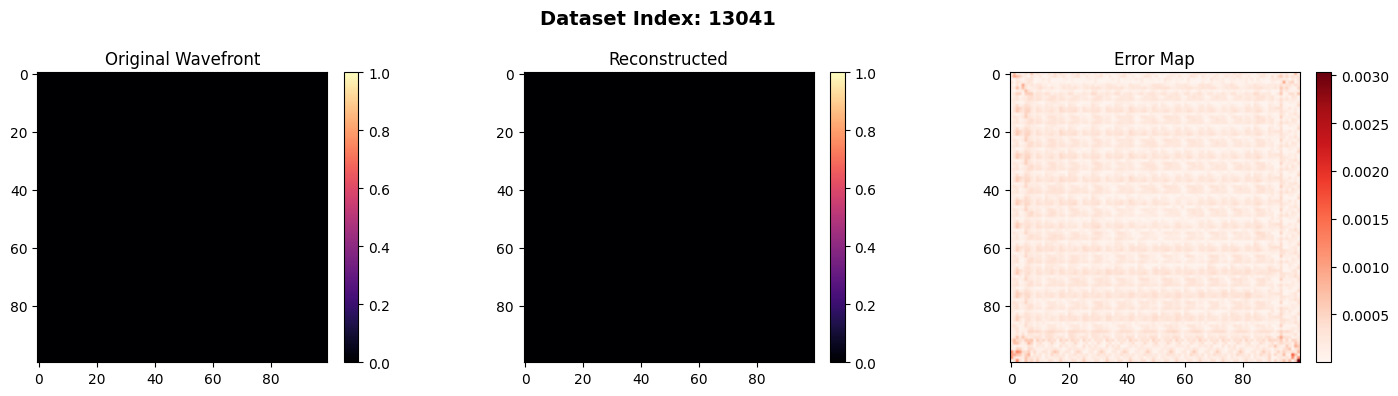

In [31]:
num_samples = 20
total_val_images = valid_data_gpu.shape[0]
random_indices = np.random.choice(total_val_images, size=num_samples, replace=False)
sample_batch = valid_data_gpu[random_indices]
z_batch = jax.vmap(trained_encoder)(sample_batch)
recon_batch = jax.vmap(trained_decoder)(z_batch)
print("Hunting for spirals...")
for i in range(num_samples):
    orig_img = np.array(sample_batch[i, 0])
    recon_img = np.array(recon_batch[i, 0])
    error_map = np.abs(orig_img - recon_img)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Dataset Index: {random_indices[i]}", fontsize=14, fontweight='bold')
    im0 = axes[0].imshow(orig_img, cmap='magma', vmin=0, vmax=1)
    axes[0].set_title('Original Wavefront')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(recon_img, cmap='magma', vmin=0, vmax=1)
    axes[1].set_title('Reconstructed')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    im2 = axes[2].imshow(error_map, cmap='Reds')
    axes[2].set_title('Error Map')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()